# 3.8 Temporal Consistency: Cosine Similarity Analysis

This notebook analyzes the temporal consistency of latent representations across multiple scans per patient.

## Research Questions:
1. How similar are a patient's latent representations across different timepoints?
2. Does the autoencoder produce stable, reproducible representations?
3. Are changes in latent space correlated with disease progression?
4. Which latent dimensions are most stable vs. most variable?

## Methods:
- Calculate cosine similarity between all pairs of scans for each patient
- Analyze similarity by time interval (baseline vs follow-up)
- Correlate similarity changes with SBR changes
- Identify stable vs variable latent dimensions

## Section 1: Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re
from scipy import stats
from scipy.spatial.distance import cosine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


### 1.1 Define Constants

In [2]:
# Feature columns
FEATURE_COLS = [f'latent_{i}' for i in range(256)]
TARGETS = ['SBR_PC1', 'SBR_PC2', 'SBR_PC3']
SBR_COLS = [
    'DATSCAN_CAUDATE_R', 'DATSCAN_CAUDATE_L',
    'DATSCAN_PUTAMEN_R', 'DATSCAN_PUTAMEN_L',
    'DATSCAN_PUTAMEN_R_ANT', 'DATSCAN_PUTAMEN_L_ANT'
]

print(f"Features: {len(FEATURE_COLS)}")
print(f"Targets: {TARGETS}")

Features: 256
Targets: ['SBR_PC1', 'SBR_PC2', 'SBR_PC3']


### 1.2 Load Data

In [3]:
df_combined = pd.read_csv('output/final_train_combined_vae_data.csv')

print(f"Combined dataset shape: {df_combined.shape}")
print(f"Unique patients in combined data: {df_combined['PATNO'].nunique()}")

# Check for multiple visits per patient
visits_per_patient = df_combined.groupby('PATNO').size()
print(f"\nVisits per patient statistics:")
print(visits_per_patient.describe())
print(f"Patients with multiple visits: {(visits_per_patient > 1).sum()}")

Combined dataset shape: (2373, 303)
Unique patients in combined data: 1437

Visits per patient statistics:
count    1437.000000
mean        1.651357
std         0.955241
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         5.000000
dtype: float64
Patients with multiple visits: 553


### 1.3 Calculate SBR PCs

In [4]:
# Calculate SBR PCs
df_with_sbr = df_combined.dropna(subset=SBR_COLS).copy()
scaler_sbr = StandardScaler()
sbr_scaled = scaler_sbr.fit_transform(df_with_sbr[SBR_COLS])
pca = PCA(n_components=3, random_state=0)
sbr_pcs = pca.fit_transform(sbr_scaled)
df_with_sbr['SBR_PC1'] = sbr_pcs[:, 0]
df_with_sbr['SBR_PC2'] = sbr_pcs[:, 1]
df_with_sbr['SBR_PC3'] = sbr_pcs[:, 2]
df_combined = df_with_sbr.copy()

print(f"Dataset with SBR PCs: {df_combined.shape}")

Dataset with SBR PCs: (2373, 306)


## Section 2: Cosine Similarity Analysis

### 2.1 Calculate Pairwise Cosine Similarities

In [5]:
print("\n" + "="*80)
print("COSINE SIMILARITY ANALYSIS")
print("="*80)

# Group by patient
patient_groups = df_combined.groupby('PATNO')

# Calculate cosine similarities
similarity_results = []

for patno, group in patient_groups:
    if len(group) < 2:
        continue  # Need at least 2 scans
    
    # Extract latent vectors
    latent_vecs = group[FEATURE_COLS].values
    
    # Calculate all pairwise cosine similarities
    n_scans = len(latent_vecs)
    similarities = []
    
    for i in range(n_scans):
        for j in range(i+1, n_scans):
            # Cosine similarity = 1 - cosine distance
            cos_sim = 1 - cosine(latent_vecs[i], latent_vecs[j])
            similarities.append(cos_sim)
    
    if len(similarities) > 0:
        # Get SBR values
        sbr_pc1_vals = group['SBR_PC1'].values
        sbr_pc2_vals = group['SBR_PC2'].values
        sbr_pc3_vals = group['SBR_PC3'].values
        
        # Calculate SBR changes
        sbr_pc1_change = np.max(sbr_pc1_vals) - np.min(sbr_pc1_vals)
        sbr_pc2_change = np.max(sbr_pc2_vals) - np.min(sbr_pc2_vals)
        sbr_pc3_change = np.max(sbr_pc3_vals) - np.min(sbr_pc3_vals)
        
        similarity_results.append({
            'PATNO': patno,
            'N_Scans': n_scans,
            'N_Pairs': len(similarities),
            'Mean_Cosine_Similarity': np.mean(similarities),
            'Std_Cosine_Similarity': np.std(similarities),
            'Min_Cosine_Similarity': np.min(similarities),
            'Max_Cosine_Similarity': np.max(similarities),
            'SBR_PC1_Change': sbr_pc1_change,
            'SBR_PC2_Change': sbr_pc2_change,
            'SBR_PC3_Change': sbr_pc3_change,
            'Mean_SBR_PC1': np.mean(sbr_pc1_vals),
            'Mean_SBR_PC2': np.mean(sbr_pc2_vals),
            'Mean_SBR_PC3': np.mean(sbr_pc3_vals)
        })

df_similarity = pd.DataFrame(similarity_results)

print(f"\nPatients with multiple scans: {len(df_similarity)}")
print(f"Total scan pairs analyzed: {df_similarity['N_Pairs'].sum()}")
print(f"\nCosine Similarity Statistics:")
print(f"  Mean: {df_similarity['Mean_Cosine_Similarity'].mean():.4f}")
print(f"  Std:  {df_similarity['Mean_Cosine_Similarity'].std():.4f}")
print(f"  Min:  {df_similarity['Mean_Cosine_Similarity'].min():.4f}")
print(f"  Max:  {df_similarity['Mean_Cosine_Similarity'].max():.4f}")


COSINE SIMILARITY ANALYSIS

Patients with multiple scans: 553
Total scan pairs analyzed: 1428

Cosine Similarity Statistics:
  Mean: 0.8008
  Std:  0.1184
  Min:  0.3840
  Max:  1.0000


### 2.2 Summary Statistics

In [6]:
print("\n" + "="*80)
print("TEMPORAL CONSISTENCY SUMMARY")
print("="*80)

print(f"\nScan Distribution:")
print(df_similarity['N_Scans'].value_counts().sort_index().to_string())

print(f"\nCosine Similarity by Number of Scans:")
for n_scans in sorted(df_similarity['N_Scans'].unique()):
    subset = df_similarity[df_similarity['N_Scans'] == n_scans]
    print(f"  {n_scans} scans (n={len(subset)}): mean={subset['Mean_Cosine_Similarity'].mean():.4f}, std={subset['Mean_Cosine_Similarity'].std():.4f}")

print(f"\nTop 10 Most Similar Patients (Highest Cosine Similarity):")
print(df_similarity.nlargest(10, 'Mean_Cosine_Similarity')[['PATNO', 'N_Scans', 'Mean_Cosine_Similarity', 'SBR_PC1_Change']].to_string(index=False))

print(f"\nTop 10 Most Variable Patients (Lowest Cosine Similarity):")
print(df_similarity.nsmallest(10, 'Mean_Cosine_Similarity')[['PATNO', 'N_Scans', 'Mean_Cosine_Similarity', 'SBR_PC1_Change']].to_string(index=False))


TEMPORAL CONSISTENCY SUMMARY

Scan Distribution:
N_Scans
2    278
3    168
4    106
5      1

Cosine Similarity by Number of Scans:
  2 scans (n=278): mean=0.8017, std=0.1278
  3 scans (n=168): mean=0.8029, std=0.1180
  4 scans (n=106): mean=0.7970, std=0.0895
  5 scans (n=1): mean=0.5763, std=nan

Top 10 Most Similar Patients (Highest Cosine Similarity):
 PATNO  N_Scans  Mean_Cosine_Similarity  SBR_PC1_Change
141713        2                1.000000        0.000000
130013        2                0.955192        1.031686
  4094        2                0.951739        0.121629
101221        2                0.949208        0.579886
153191        3                0.945175        0.635839
100017        2                0.941951        0.653529
  4024        3                0.941594        0.598166
 50028        2                0.940082        0.338965
  4052        2                0.939769        0.411777
  3229        3                0.938874        1.595576

Top 10 Most Variable Pat

### 2.3 Correlation with SBR Changes

In [7]:
print("\n" + "="*80)
print("CORRELATION: COSINE SIMILARITY vs SBR CHANGES")
print("="*80)

# Correlate cosine similarity with SBR changes
for target in ['SBR_PC1_Change', 'SBR_PC2_Change', 'SBR_PC3_Change']:
    # Remove NaN values
    valid_data = df_similarity.dropna(subset=['Mean_Cosine_Similarity', target])
    
    if len(valid_data) > 2:
        corr, p_val = stats.pearsonr(valid_data['Mean_Cosine_Similarity'], valid_data[target])
        print(f"\n{target}:")
        print(f"  Pearson r: {corr:.4f}")
        print(f"  p-value: {p_val:.4e}")
        
        if p_val < 0.05:
            print(f"  → Significant correlation (p<0.05)")
        else:
            print(f"  → No significant correlation (p≥0.05)")


CORRELATION: COSINE SIMILARITY vs SBR CHANGES

SBR_PC1_Change:
  Pearson r: -0.1602
  p-value: 1.5456e-04
  → Significant correlation (p<0.05)

SBR_PC2_Change:
  Pearson r: -0.1449
  p-value: 6.3398e-04
  → Significant correlation (p<0.05)

SBR_PC3_Change:
  Pearson r: -0.1510
  p-value: 3.6698e-04
  → Significant correlation (p<0.05)


## Section 3: Latent Dimension Stability

### 3.1 Identify Stable vs Variable Dimensions

In [8]:
print("\n" + "="*80)
print("LATENT DIMENSION STABILITY ANALYSIS")
print("="*80)

# For each latent dimension, calculate variance across scans per patient
dimension_stability = []

for dim_idx in range(len(FEATURE_COLS)):
    dim_name = FEATURE_COLS[dim_idx]
    
    # Calculate coefficient of variation for each patient
    cv_values = []
    
    for patno, group in patient_groups:
        if len(group) < 2:
            continue
        
        dim_values = group[dim_name].values
        mean_val = np.mean(dim_values)
        std_val = np.std(dim_values)
        
        if mean_val != 0:
            cv = std_val / np.abs(mean_val)
            cv_values.append(cv)
    
    if len(cv_values) > 0:
        dimension_stability.append({
            'Dimension': dim_name,
            'Mean_CV': np.mean(cv_values),
            'Std_CV': np.std(cv_values),
            'Median_CV': np.median(cv_values)
        })

df_stability = pd.DataFrame(dimension_stability)
df_stability = df_stability.sort_values('Mean_CV')

print(f"\nMost Stable Dimensions (Low Coefficient of Variation):")
print(df_stability.head(10)[['Dimension', 'Mean_CV', 'Std_CV']].to_string(index=False))

print(f"\nMost Variable Dimensions (High Coefficient of Variation):")
print(df_stability.tail(10)[['Dimension', 'Mean_CV', 'Std_CV']].to_string(index=False))


LATENT DIMENSION STABILITY ANALYSIS

Most Stable Dimensions (Low Coefficient of Variation):
 Dimension  Mean_CV   Std_CV
 latent_38 0.110176 0.131704
 latent_92 0.120404 0.190877
 latent_48 0.125644 0.147060
latent_216 0.170770 0.297326
 latent_40 0.213098 0.979749
 latent_19 0.247896 0.355804
latent_244 0.271296 0.365998
 latent_84 0.274382 0.499203
latent_221 0.282876 0.764539
latent_139 0.284088 0.366001

Most Variable Dimensions (High Coefficient of Variation):
 Dimension    Mean_CV       Std_CV
latent_159  15.338731   300.335752
 latent_86  17.416246   350.372861
latent_137  20.498431   410.242406
latent_191  21.200778   396.791473
 latent_17  21.657333   469.702931
latent_125  97.116777  2198.163400
latent_130 109.230645  2518.666322
latent_127 245.365041  5720.844947
latent_109 404.459476  9443.529742
 latent_24 489.415997 11453.318321


## Section 4: Visualizations

### 4.1 Cosine Similarity Distribution

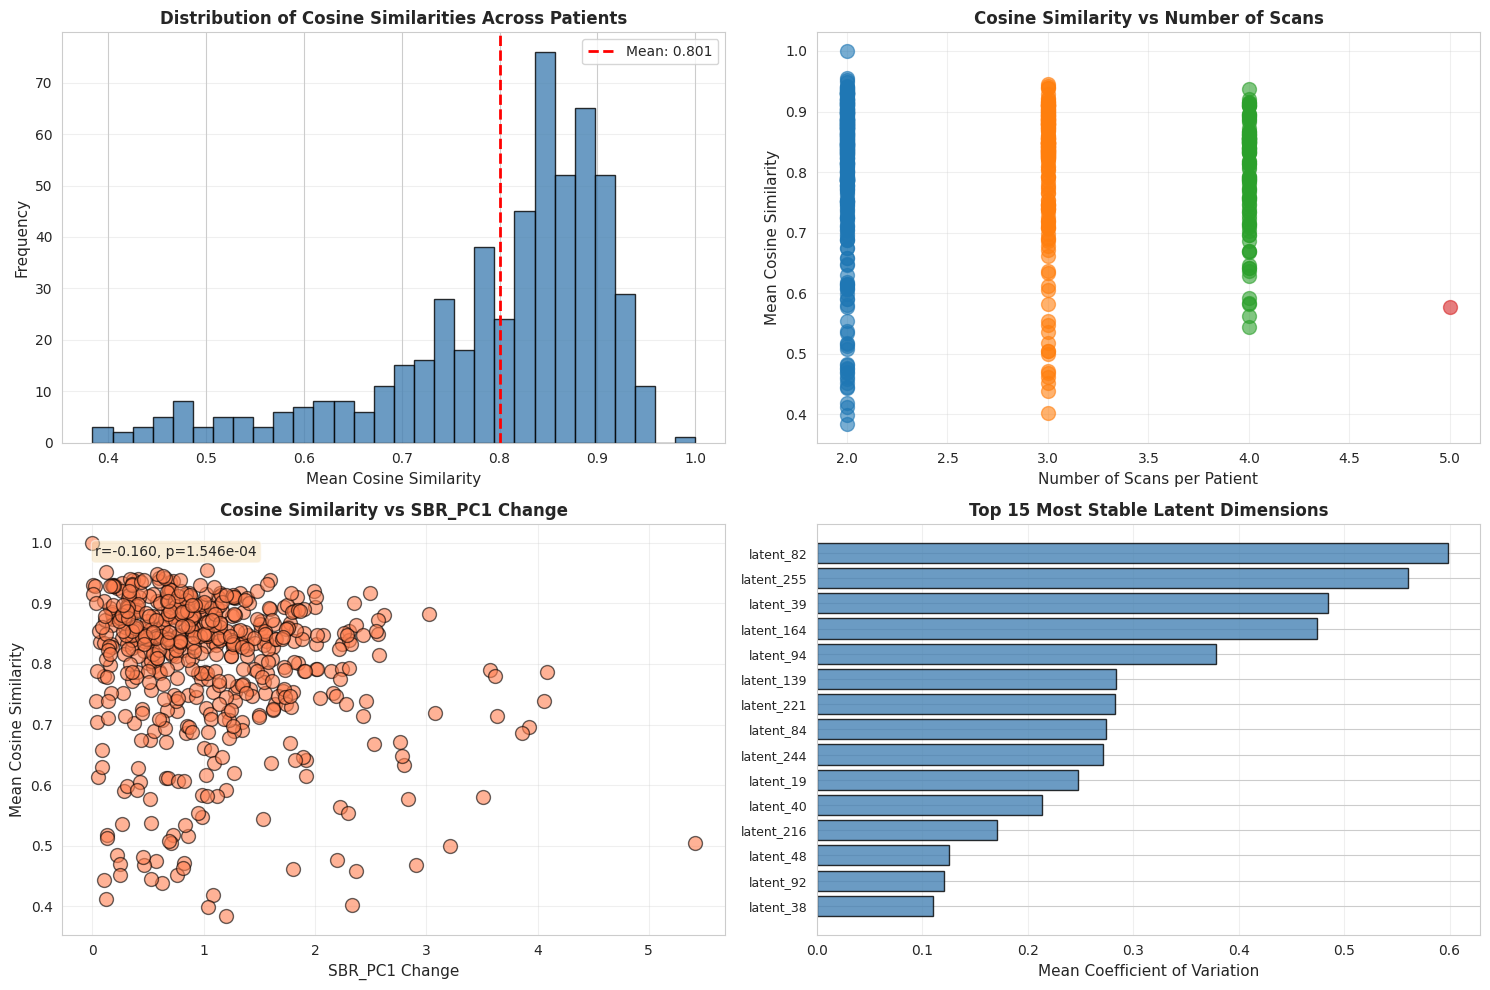

Plot saved to: output/cosine_similarity_analysis.png


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Histogram of mean cosine similarities
axes[0, 0].hist(df_similarity['Mean_Cosine_Similarity'], bins=30, color='steelblue', alpha=0.8, edgecolor='black')
axes[0, 0].axvline(df_similarity['Mean_Cosine_Similarity'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df_similarity['Mean_Cosine_Similarity'].mean():.3f}")
axes[0, 0].set_xlabel('Mean Cosine Similarity', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Distribution of Cosine Similarities Across Patients', fontsize=12, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Cosine similarity by number of scans
for n_scans in sorted(df_similarity['N_Scans'].unique()):
    subset = df_similarity[df_similarity['N_Scans'] == n_scans]
    axes[0, 1].scatter([n_scans]*len(subset), subset['Mean_Cosine_Similarity'], alpha=0.6, s=100, label=f"n={len(subset)}")

axes[0, 1].set_xlabel('Number of Scans per Patient', fontsize=11)
axes[0, 1].set_ylabel('Mean Cosine Similarity', fontsize=11)
axes[0, 1].set_title('Cosine Similarity vs Number of Scans', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Cosine similarity vs SBR_PC1 change
axes[1, 0].scatter(df_similarity['SBR_PC1_Change'], df_similarity['Mean_Cosine_Similarity'], alpha=0.6, s=100, color='coral', edgecolor='black')
axes[1, 0].set_xlabel('SBR_PC1 Change', fontsize=11)
axes[1, 0].set_ylabel('Mean Cosine Similarity', fontsize=11)
axes[1, 0].set_title('Cosine Similarity vs SBR_PC1 Change', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Add correlation
valid_data = df_similarity.dropna(subset=['Mean_Cosine_Similarity', 'SBR_PC1_Change'])
if len(valid_data) > 2:
    corr, p_val = stats.pearsonr(valid_data['Mean_Cosine_Similarity'], valid_data['SBR_PC1_Change'])
    axes[1, 0].text(0.05, 0.95, f'r={corr:.3f}, p={p_val:.3e}', transform=axes[1, 0].transAxes, 
                    fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Dimension stability
top_stable = df_stability.head(15)
axes[1, 1].barh(range(len(top_stable)), top_stable['Mean_CV'].values, color='steelblue', alpha=0.8, edgecolor='black')
axes[1, 1].set_yticks(range(len(top_stable)))
axes[1, 1].set_yticklabels(top_stable['Dimension'].values, fontsize=9)
axes[1, 1].set_xlabel('Mean Coefficient of Variation', fontsize=11)
axes[1, 1].set_title('Top 15 Most Stable Latent Dimensions', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('output/cosine_similarity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved to: output/cosine_similarity_analysis.png")

## Section 5: Save Results

In [10]:
output_dir = Path('output')

# Save similarity results
df_similarity.to_csv(output_dir / 'cosine_similarity_by_patient.csv', index=False)

# Save dimension stability
df_stability.to_csv(output_dir / 'latent_dimension_stability.csv', index=False)

print("Results saved to:")
print(f"  - {output_dir / 'cosine_similarity_by_patient.csv'}")
print(f"  - {output_dir / 'latent_dimension_stability.csv'}")

print(f"\nSimilarity Summary:")
print(df_similarity[['PATNO', 'N_Scans', 'Mean_Cosine_Similarity', 'SBR_PC1_Change']].head(20).to_string(index=False))

Results saved to:
  - output/cosine_similarity_by_patient.csv
  - output/latent_dimension_stability.csv

Similarity Summary:
 PATNO  N_Scans  Mean_Cosine_Similarity  SBR_PC1_Change
  3001        4                0.641651        1.918209
  3002        4                0.696592        3.926333
  3003        3                0.546944        0.983967
  3010        3                0.753838        1.279942
  3012        4                0.636041        1.602792
  3014        2                0.831374        0.598671
  3018        2                0.847480        0.645535
  3020        4                0.758505        1.412282
  3024        2                0.802234        0.502408
  3027        2                0.843006        0.700048
  3028        3                0.848506        1.394743
  3050        2                0.614989        1.919478
  3051        3                0.661978        0.998888
  3052        4                0.883068        0.782615
  3054        3                0.84